# Estimating a Stock's Market Beta with Linear Regression

**Question:** how much does Apple (AAPL) move when the overall market moves?

We estimate this with a single-variable linear regression: `AAPL_return = beta * SPY_return + alpha`.
The slope of that line, **beta**, is a real, widely-used finance number (it's the "systematic risk"
number quoted on every stock research page). If beta = 1.2, AAPL tends to move about 20% more than
the market on a given day, in the same direction.

**Why returns, not raw prices?** Stock prices are close to a random walk — regressing tomorrow's price
on today's price looks like a great model (very high R²) purely because prices don't jump much day to
day, not because anything real was learned. Daily *returns* (percent change) don't have that problem,
which is why beta is always computed on returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## 1. Pull the data

Two tickers, two years of daily prices:
- `AAPL` — the stock we're analyzing
- `SPY` — an ETF that tracks the S&P 500, used as a stand-in for "the market"

In [2]:
stock_ticker = "AAPL"
market_ticker = "SPY"

raw = yf.download([stock_ticker, market_ticker], period="2y", auto_adjust=True, progress=False)
prices = raw["Close"].dropna()
prices.tail()

Ticker,AAPL,SPY
Date,,
2026-09-01,325.130005,761.780029
2026-09-02,324.959991,765.159973
2026-09-03,328.209991,773.169983
2026-09-04,319.970001,770.190002
2026-09-08,316.220001,765.960022


## 2. Convert prices to daily returns

`pct_change()` turns each price into "percent change from the previous trading day" — this is the
return. The first row becomes `NaN` (there's no previous day to compare it to), so we drop it.

In [3]:
returns = prices.pct_change().dropna()
returns.columns = ["stock_return", "market_return"]
returns.tail()

,stock_return,market_return
Date,,
2026-09-01,0.026132,-0.006870
2026-09-02,-0.000523,0.004437
2026-09-03,0.010001,0.010468
2026-09-04,-0.025106,-0.003854
2026-09-08,-0.011720,-0.005492


## 3. Split into train and test periods

We fit the line on the *earlier* part of the data and test it on the *later* part — not a random
shuffle. That mirrors how the model would actually be used (fit on the past, evaluate on data it
hasn't seen), and it's an honest check that the relationship isn't just an artifact of one period.

In [4]:
X = returns[["market_return"]]   # predictor: the market's daily return
y = returns["stock_return"]       # target: the stock's daily return

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"train days: {len(X_train)}, test days: {len(X_test)}")

train days: 399, test days: 100


## 4. Fit the regression

`LinearRegression().fit()` finds the slope (beta) and intercept (alpha) that best fit
`stock_return = beta * market_return + alpha` on the training data.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

beta = model.coef_[0]
alpha = model.intercept_

print(f"beta (slope):     {beta:.3f}")
print(f"alpha (intercept): {alpha:.5f}")

beta (slope):     1.176
alpha (intercept): -0.00019


## 5. Evaluate: in-sample vs. out-of-sample

**R² (coefficient of determination):** the fraction of the stock's day-to-day return variation
that's explained by the market's return. R² = 1 would mean the market perfectly explains the
stock's moves; R² = 0 means the market explains none of it; R² can even go *negative* on new data
if the fitted line predicts worse than just guessing the average return.

We check R² on both the training period (data the model was fit on) and the test period (data it
wasn't). A meaningful gap between the two is itself a finding — it tells us whether "AAPL moves
with the market" is a stable relationship or one that drifted.

In [6]:
train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print(f"train R^2 ({X_train.index.min().date()} to {X_train.index.max().date()}): {train_r2:.3f}")
print(f"test R^2  ({X_test.index.min().date()} to {X_test.index.max().date()}): {test_r2:.3f}")
print()
print("correlation, train:", round(X_train['market_return'].corr(y_train), 3))
print("correlation, test: ", round(X_test['market_return'].corr(y_test), 3))
print()
print("daily return volatility (std dev):")
print(f"  {stock_ticker} - train: {y_train.std():.4f}   test: {y_test.std():.4f}")
print(f"  {market_ticker} - train: {X_train['market_return'].std():.4f}   test: {X_test['market_return'].std():.4f}")

train R^2 (2024-09-11 to 2026-04-15): 0.501
test R^2  (2026-04-16 to 2026-09-08): -0.100

correlation, train: 0.708
correlation, test:  0.158

daily return volatility (std dev):
  AAPL - train: 0.0182   test: 0.0182
  SPY - train: 0.0110   test: 0.0079


**As a sanity check**, we also fit the same regression on the *entire* two years at once (no
train/test split) — this is closer to how beta is normally reported, and it's useful to compare
against published beta figures for the stock.

In [7]:
full_model = LinearRegression().fit(X, y)
full_r2 = r2_score(y, full_model.predict(X))
print(f"full-period beta: {full_model.coef_[0]:.3f}")
print(f"full-period R^2:  {full_r2:.3f}")

y_pred = model.predict(X_test)   # test-set predictions, used in the plots below
r2 = test_r2

full-period beta: 1.085
full-period R^2:  0.385


## 6. Visualize: predicted vs. actual returns

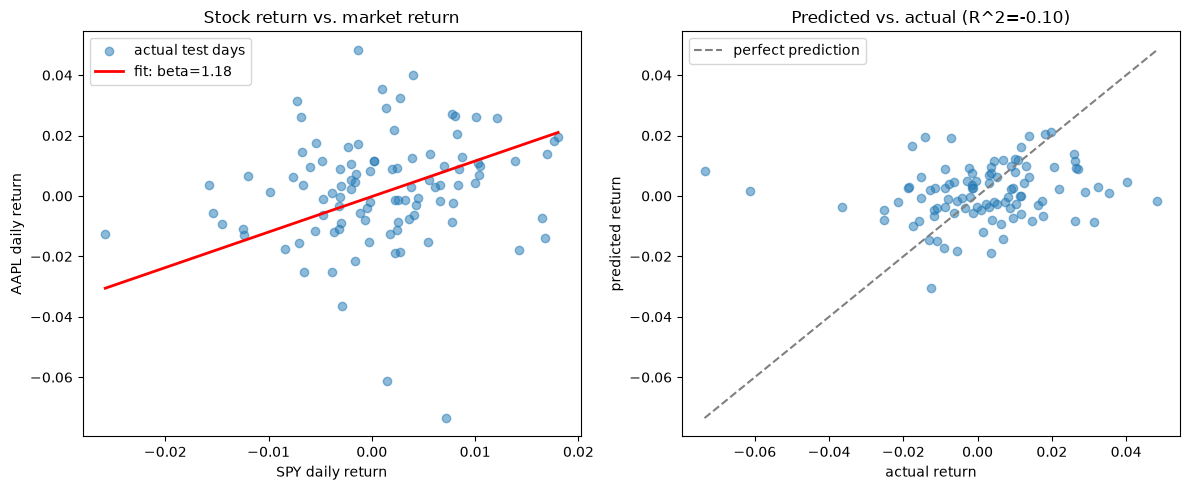

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: the fitted line against the raw scatter of returns
axes[0].scatter(X_test, y_test, alpha=0.5, label="actual test days")
line_x = pd.DataFrame({"market_return": np.linspace(X_test.values.min(), X_test.values.max(), 100)})
axes[0].plot(line_x, model.predict(line_x), color="red", linewidth=2, label=f"fit: beta={beta:.2f}")
axes[0].set_xlabel(f"{market_ticker} daily return")
axes[0].set_ylabel(f"{stock_ticker} daily return")
axes[0].set_title("Stock return vs. market return")
axes[0].legend()

# right: predicted vs actual, a perfect model would fall on the diagonal
axes[1].scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="gray", linestyle="--", label="perfect prediction")
axes[1].set_xlabel("actual return")
axes[1].set_ylabel("predicted return")
axes[1].set_title(f"Predicted vs. actual (R^2={r2:.2f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("beta_regression_plot.png", dpi=120)
plt.show()

## 7. What this does and doesn't tell us

- **Beta** says how sensitive AAPL's daily returns are historically to S&P 500 daily returns — a
  beta above 1 means it tends to amplify market moves; below 1 means it dampens them. The
  full-period estimate above (computed with no train/test split) is the one to compare against
  published beta figures.
- **R² says how much of AAPL's day-to-day movement the market explains.** The gap between train
  R² and test R² is the real headline finding here: this relationship was much weaker in the most
  recent stretch of data than in the training period — meaning "AAPL moves with the market" is not
  a fixed law, it's a historical tendency that can drift, especially during a run of stock-specific
  news. This is exactly why real beta estimates are usually recomputed on a rolling basis rather
  than treated as a constant.
- **This is not a trading signal.** A high beta doesn't mean "buy" or "sell," and this model says
  nothing about whether AAPL is a good investment — only how it has co-moved with the market.